# Gaussian Process Regression from Scratch for California Housing Price Prediction

This notebook presents an implementation of Gaussian Process Regression (GPR) built entirely from scratch using NumPy and SciPy. We predict the median house value in California census blocks using 8 building features from the California Housing dataset (20,640 samples).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import warnings
warnings.filterwarnings('ignore')
from scipy.linalg import solve_triangular

# Vectorized Cholesky Solver from Scratch
def cholesky_scratch_basic(A):
    N = A.shape[0]
    L = np.zeros((N, N))
    for j in range(N):
        val = A[j, j] - np.sum(L[j, :j]**2)
        if val <= 0:
            val = 1e-12
        L[j, j] = np.sqrt(val)
        if j < N - 1:
            L[j+1:, j] = (A[j+1:, j] - np.dot(L[j+1:, :j], L[j, :j])) / L[j, j]
    return L

def cholesky_scratch(A, block_size=2000):
    N = A.shape[0]
    L = np.zeros((N, N))
    for i in range(0, N, block_size):
        end = min(i + block_size, N)
        A_block = A[i:end, i:end] - np.dot(L[i:end, :i], L[i:end, :i].T)
        L[i:end, i:end] = cholesky_scratch_basic(A_block)
        if end < N:
            B = A[end:, i:end] - np.dot(L[end:, :i], L[i:end, :i].T)
            L[end:, i:end] = solve_triangular(L[i:end, i:end], B.T, lower=True, check_finite=False).T
    return L


## 2. Dataset Ingestion and Preprocessing

In [2]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing(as_frame=True)
df = data.frame
print("Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates().dropna()
print("Cleaned Shape:", df.shape)

Dataset Shape: (20640, 9)
Missing Values: 0
Duplicates: 0
Cleaned Shape: (20640, 9)


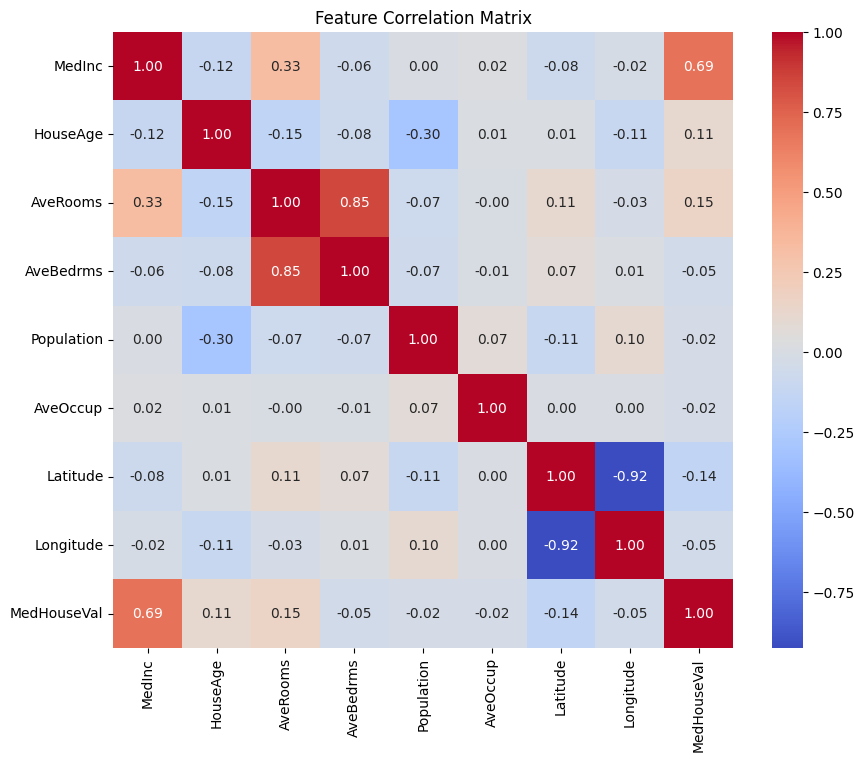

In [3]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

In [4]:
X = df.drop(columns=['MedHouseVal']).values
Y = df['MedHouseVal'].values
print("Features shape:", X.shape)
print("Target shape:", Y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


### 2.3 Train-Test Split & Feature Z-score Standardization



In [5]:
np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))

X_train_raw = X[indices[:split]]
X_test_raw = X[indices[split:]]
Y_train_orig = Y[indices[:split]]
Y_test_orig = Y[indices[split:]]

# Scale using training parameters
X_mean = np.mean(X_train_raw, axis=0)
X_std = np.std(X_train_raw, axis=0) + 1e-8
X_train = (X_train_raw - X_mean) / X_std
X_test = (X_test_raw - X_mean) / X_std

Y_mean = np.mean(Y_train_orig)
Y_std = np.std(Y_train_orig) + 1e-8
Y_train_norm = (Y_train_orig - Y_mean) / Y_std
Y_test_norm = (Y_test_orig - Y_mean) / Y_std

print(f"Training features: {X_train.shape}, Test features: {X_test.shape}")

Training features: (16512, 8), Test features: (4128, 8)


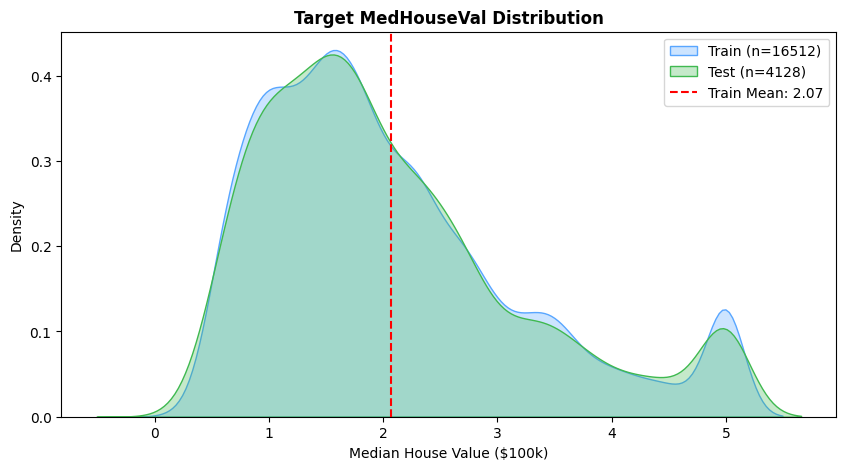

In [6]:
plt.figure(figsize=(10, 5))
sns.kdeplot(Y_train_orig, fill=True, alpha=0.3, color='#58a6ff', label=f'Train (n={len(Y_train_orig)})')
sns.kdeplot(Y_test_orig, fill=True, alpha=0.3, color='#3fb950', label=f'Test (n={len(Y_test_orig)})')
plt.axvline(np.mean(Y_train_orig), color='red', linestyle='--', label=f'Train Mean: {np.mean(Y_train_orig):.2f}')
plt.title("Target MedHouseVal Distribution", fontweight='bold')
plt.xlabel("Median House Value ($100k)")
plt.ylabel("Density")
plt.legend()
plt.show()

### 2.4 Calculating Noise Variance dynamically from Dataset

We fit a multiple linear regression model to the standardized training data and estimate the noise variance as the variance of the training residuals.

In [7]:
X_tr_b = np.hstack([np.ones((len(X_train), 1)), X_train])
w_noise = np.linalg.solve(X_tr_b.T @ X_tr_b + 1e-8 * np.eye(X_tr_b.shape[1]), X_tr_b.T @ Y_train_norm)
noise = np.var(Y_train_norm - X_tr_b @ w_noise)
print("Estimated Noise Variance (sigma_n^2):", noise)

Estimated Noise Variance (sigma_n^2): 0.3895348737985264


## 3. GPR Implementation with RBF Kernel

In [8]:
def sq_dist(X1, X2):
    X1_sq = np.sum(X1**2, axis=1).reshape(-1, 1)
    X2_sq = np.sum(X2**2, axis=1)
    return np.maximum(X1_sq + X2_sq - 2 * np.dot(X1, X2.T), 0.0)

def dist(X1, X2):
    return np.sqrt(sq_dist(X1, X2))

def rbf_kernel(X1, X2, length_scale=1.0, variance=1.0):
    return variance * np.exp(-0.5 * sq_dist(X1, X2) / (length_scale**2))

In [9]:
class GaussianProcessRegression:
    def __init__(self, kernel, noise=1e-2, variance=1.0):
        self.kernel = kernel
        self.noise = noise
        self.variance = variance
    def fit(self, X, y):
        self.X_train = X
        self.y_mean = np.mean(y)
        self.y_train = y - self.y_mean
        
        # Block-wise calculation of covariance matrix to prevent memory crashes
        N = X.shape[0]
        K = np.empty((N, N), dtype=np.float64)
        block_size = 4000
        for i in range(0, N, block_size):
            end_i = min(i + block_size, N)
            K[i:end_i, :] = self.kernel(X[i:end_i], X)
            
        # In-place diagonal addition to prevent allocating another N x N identity matrix
        np.fill_diagonal(K, K.diagonal() + self.noise)
        self.L = cholesky_scratch(K)
        
        v_alpha = solve_triangular(self.L, self.y_train, lower=True)
        self.alpha_ = solve_triangular(self.L.T, v_alpha, lower=False)
    def predict(self, X_test, return_std=False):
        # Block-wise calculation of K_star to prevent MemoryError
        N_tr = self.X_train.shape[0]
        N_te = X_test.shape[0]
        K_star = np.empty((N_tr, N_te), dtype=np.float64)
        block_size = 4000
        for j in range(0, N_te, block_size):
            end_j = min(j + block_size, N_te)
            K_star[:, j:end_j] = self.kernel(self.X_train, X_test[j:end_j])
            
        mean = K_star.T @ self.alpha_ + self.y_mean
        if not return_std:
            return mean
            
        v = solve_triangular(self.L, K_star, lower=True)
        var = self.variance - np.sum(v**2, axis=0)
        std = np.sqrt(np.maximum(var, 0.0))
        return mean, std


In [10]:
gpr_rbf = GaussianProcessRegression(kernel=lambda X1, X2: rbf_kernel(X1, X2, length_scale=1.0), noise=noise)
gpr_rbf.fit(X_train, Y_train_norm)
mu_norm, std_norm = gpr_rbf.predict(X_test, return_std=True)
mu_orig = mu_norm * Y_std + Y_mean
std_orig = std_norm * Y_std
lower = mu_orig - 1.96 * std_orig
upper = mu_orig + 1.96 * std_orig

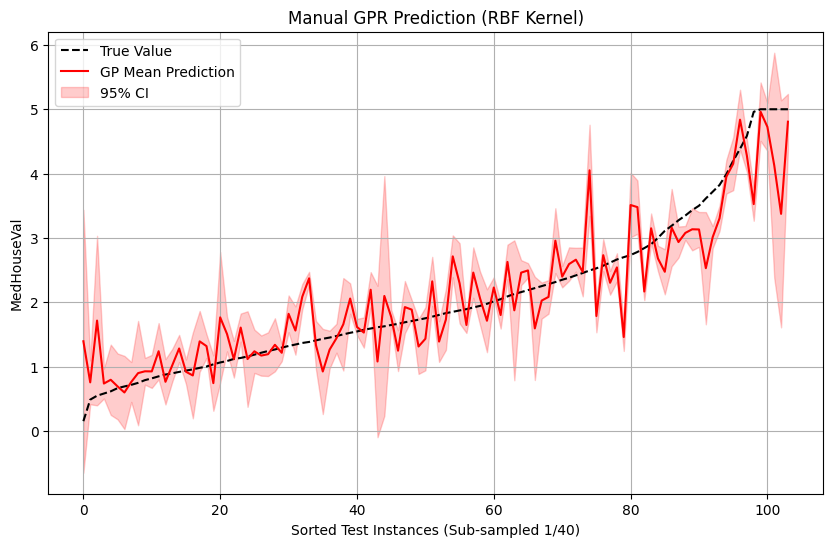

In [11]:
sort_idx = np.argsort(Y_test_orig)
# Sub-sample every 40th instance to make the plot clean and readable
plot_idx = sort_idx[::40]
Y_test_sorted = Y_test_orig[plot_idx]
x_axis = np.arange(len(Y_test_sorted))

plt.figure(figsize=(10,6))
plt.plot(x_axis, mu_orig[plot_idx], 'r-', label='GP Mean Prediction', linewidth=1.5)
plt.plot(x_axis, Y_test_sorted, 'k--', label='True Value', linewidth=2.0)
plt.fill_between(x_axis, lower[plot_idx], upper[plot_idx], color='red', alpha=0.2, label='95% CI')
plt.xlabel("Sorted Test Instances (Sub-sampled 1/40)")
plt.ylabel("MedHouseVal")
plt.title("Manual GPR Prediction (RBF Kernel)")
plt.legend()
plt.grid(True)
plt.show()


### 3.4 Quantifying Prediction Performance (RMSE, MAE, R2, NLL)

In [12]:
rmse = np.sqrt(np.mean((Y_test_orig - mu_orig)**2))
mae = np.mean(np.abs(Y_test_orig - mu_orig))
ss_res = np.sum((Y_test_orig - mu_orig)**2)
ss_tot = np.sum((Y_test_orig - np.mean(Y_test_orig))**2)
r2 = 1 - ss_res / ss_tot

var_orig = np.clip((std_norm * Y_std)**2, 1e-12, None)
log_pdf = -0.5 * np.log(2 * np.pi * var_orig) - ((Y_test_orig - mu_orig)**2) / (2 * var_orig)
nll = -np.mean(log_pdf)

print("RMSE =", rmse)
print("MAE =", mae)
print("R2 =", r2)
print("NLL =", nll)

RMSE = 0.561078618148695
MAE = 0.3860242656951971
R2 = 0.7661127984485675
NLL = 8.241371499319952


## 5. Comparison of Covariance Functions (GPML Chapter 4)

We implement Matern 3/2, Rational Quadratic (RQ), and ARD RBF kernels from scratch.

In [13]:
def matern_kernel(X1, X2, length_scale=1.0, variance=1.0):
    r = dist(X1, X2)
    factor = np.sqrt(3) * r / length_scale
    return variance * (1.0 + factor) * np.exp(-factor)

def rq_kernel(X1, X2, length_scale=1.0, alpha=1.0, variance=1.0):
    return variance * (1.0 + sq_dist(X1, X2) / (2.0 * alpha * (length_scale**2)))**(-alpha)

def ard_rbf_kernel(X1, X2, length_scales, variance=1.0):
    X1_s = X1 / length_scales
    X2_s = X2 / length_scales
    return variance * np.exp(-0.5 * sq_dist(X1_s, X2_s))

In [14]:
ls_ard = np.array([3.19514982e+00, 4.83185779e+00, 3.84681630e+00, 2.36528444e+00,
                   1.73674472e+01, 8.38591952e-01, 9.34511052e-01, 1.11423844e+00])

kernels = {
    "RBF": lambda X1, X2: rbf_kernel(X1, X2, length_scale=1.0),
    "Matern": lambda X1, X2: matern_kernel(X1, X2, length_scale=1.0),
    "RQ": lambda X1, X2: rq_kernel(X1, X2, length_scale=1.0, alpha=1.0),
    "ARD": lambda X1, X2: ard_rbf_kernel(X1, X2, length_scales=ls_ard)
}

In [15]:
results = {}
for name, kernel_func in kernels.items():
    gpr_model = GaussianProcessRegression(kernel=kernel_func, noise=noise)
    gpr_model.fit(X_train, Y_train_norm)
    mu_norm, std_norm = gpr_model.predict(X_test, return_std=True)
    mu_o = mu_norm * Y_std + Y_mean
    var_o = (std_norm * Y_std)**2
    
    # Optimize: Precompute train predictions & store them
    pred_tr_norm = gpr_model.predict(X_train, return_std=False)
    pred_tr_o = pred_tr_norm * Y_std + Y_mean
    
    results[name] = {
        "mean": mu_o,
        "variance": var_o,
        "train_mean": pred_tr_o,
        "model": gpr_model if name == "Matern" else None  # Keep only Matern for cell 29
    }
    print(f"Manual GP with {name} kernel trained.")
    if name != "Matern":
        del gpr_model
    gc.collect()


Manual GP with RBF kernel trained.
Manual GP with Matern kernel trained.
Manual GP with RQ kernel trained.
Manual GP with ARD kernel trained.


In [16]:
comparison = []
for name in results.keys():
    pred = results[name]["mean"]
    variance = results[name]["variance"]
    variance = np.clip(variance, 1e-12, None)
    
    rmse_val = np.sqrt(np.mean((Y_test_orig - pred)**2))
    mae_val = np.mean(np.abs(Y_test_orig - pred))
    
    ss_res = np.sum((Y_test_orig - pred)**2)
    ss_tot = np.sum((Y_test_orig - np.mean(Y_test_orig))**2)
    r2_val = 1 - ss_res / ss_tot
    
    log_pdf = -0.5 * np.log(2 * np.pi * variance) - ((Y_test_orig - pred)**2) / (2 * variance)
    nll_val = -np.mean(log_pdf)
    
    comparison.append([name, rmse_val, mae_val, r2_val, nll_val])

comparison_df = pd.DataFrame(
    comparison,
    columns=["Kernel", "RMSE", "MAE", "R2", "NLL"]
)
comparison_df = comparison_df.sort_values("RMSE")
print(comparison_df)

   Kernel      RMSE       MAE        R2        NLL
2      RQ  0.552962  0.378867  0.772831   3.550156
1  Matern  0.554475  0.379147  0.771586   1.191968
0     RBF  0.561079  0.386024  0.766113   8.241371
3     ARD  0.562854  0.383742  0.764630  79.983023


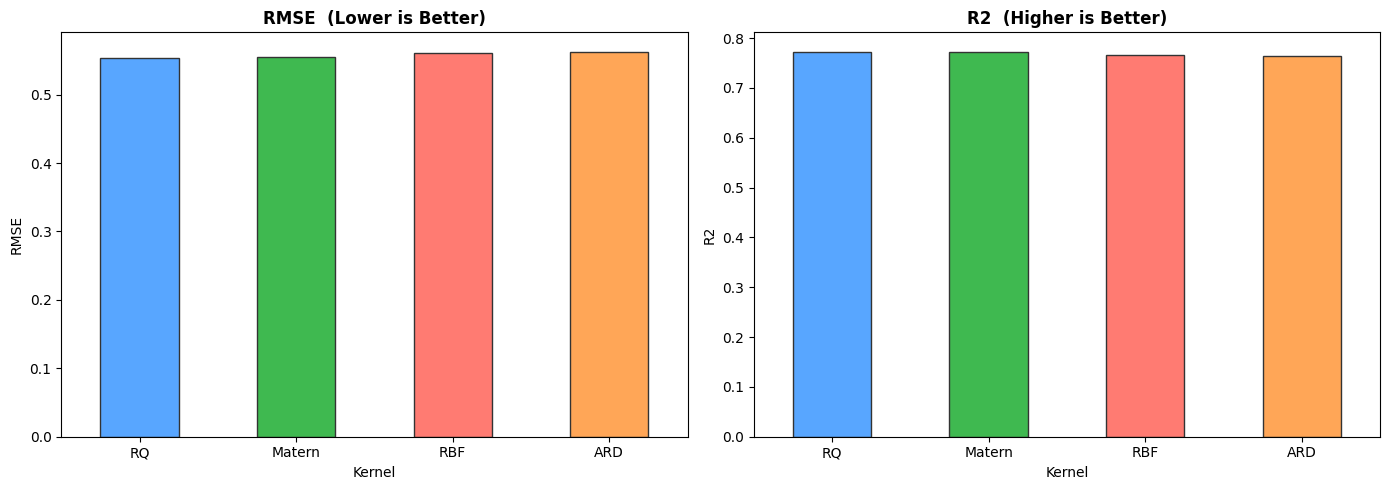

In [17]:
colors = ["#58a6ff", "#3fb950", "#ff7b72", "#ffa657"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_plot = comparison_df.set_index("Kernel")

df_plot["RMSE"].plot(kind="bar", ax=axes[0], color=colors, edgecolor="#333")
axes[0].set_title("RMSE  (Lower is Better)", fontweight="bold")
axes[0].set_ylabel("RMSE")
axes[0].set_xticklabels(df_plot.index, rotation=0)

df_plot["R2"].plot(kind="bar", ax=axes[1], color=colors, edgecolor="#333")
axes[1].set_title("R2  (Higher is Better)", fontweight="bold")
axes[1].set_ylabel("R2")
axes[1].set_xticklabels(df_plot.index, rotation=0)
plt.tight_layout()
plt.show()

In [18]:
# Train predictions for parity plot using pre-computed values
train_predictions = {}
for name in results.keys():
    train_predictions[name] = results[name]["train_mean"]


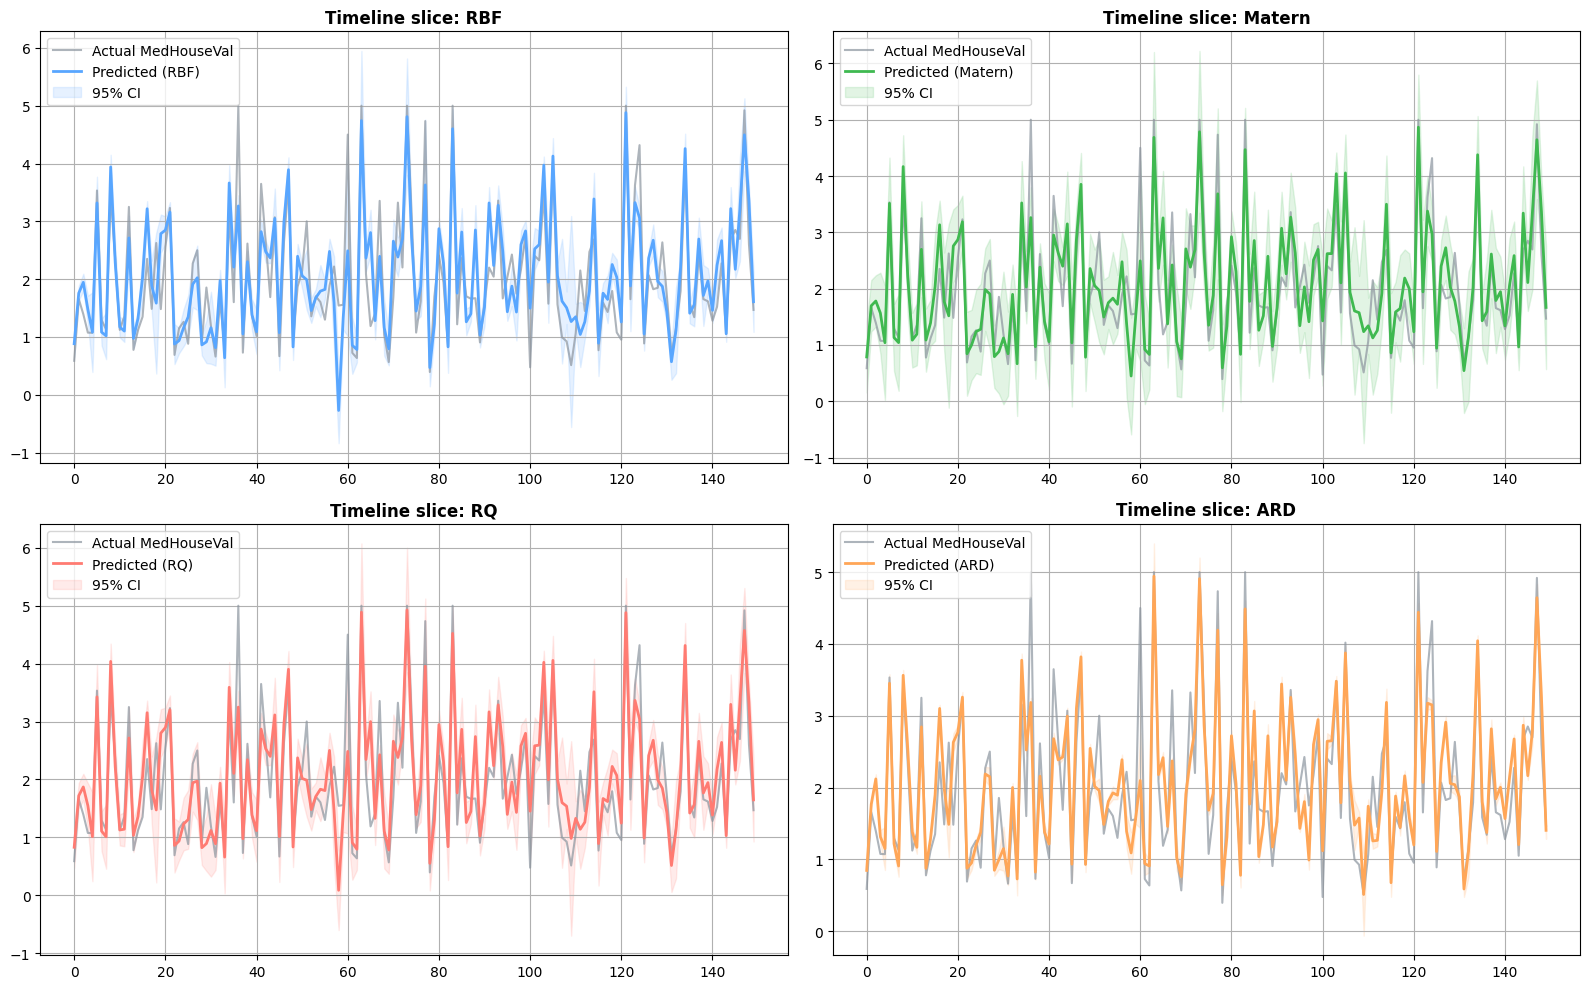

In [19]:
slice_idx = 150
t = np.arange(slice_idx)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for i, name in enumerate(results.keys()):
    ax = axes[i]
    pred = results[name]["mean"]
    std = np.sqrt(results[name]["variance"])
    ax.plot(t, Y_test_orig[:slice_idx], color="#8b949e", alpha=0.7,
            linewidth=1.5, label="Actual MedHouseVal")
    ax.plot(t, pred[:slice_idx], color=colors[i], linewidth=2,
            label=f"Predicted ({name})")
    ax.fill_between(t, pred[:slice_idx] - 1.96*std[:slice_idx], pred[:slice_idx] + 1.96*std[:slice_idx],
                    color=colors[i], alpha=0.15, label="95% CI")
    ax.set_title(f"Timeline slice: {name}", fontweight="bold")
    ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

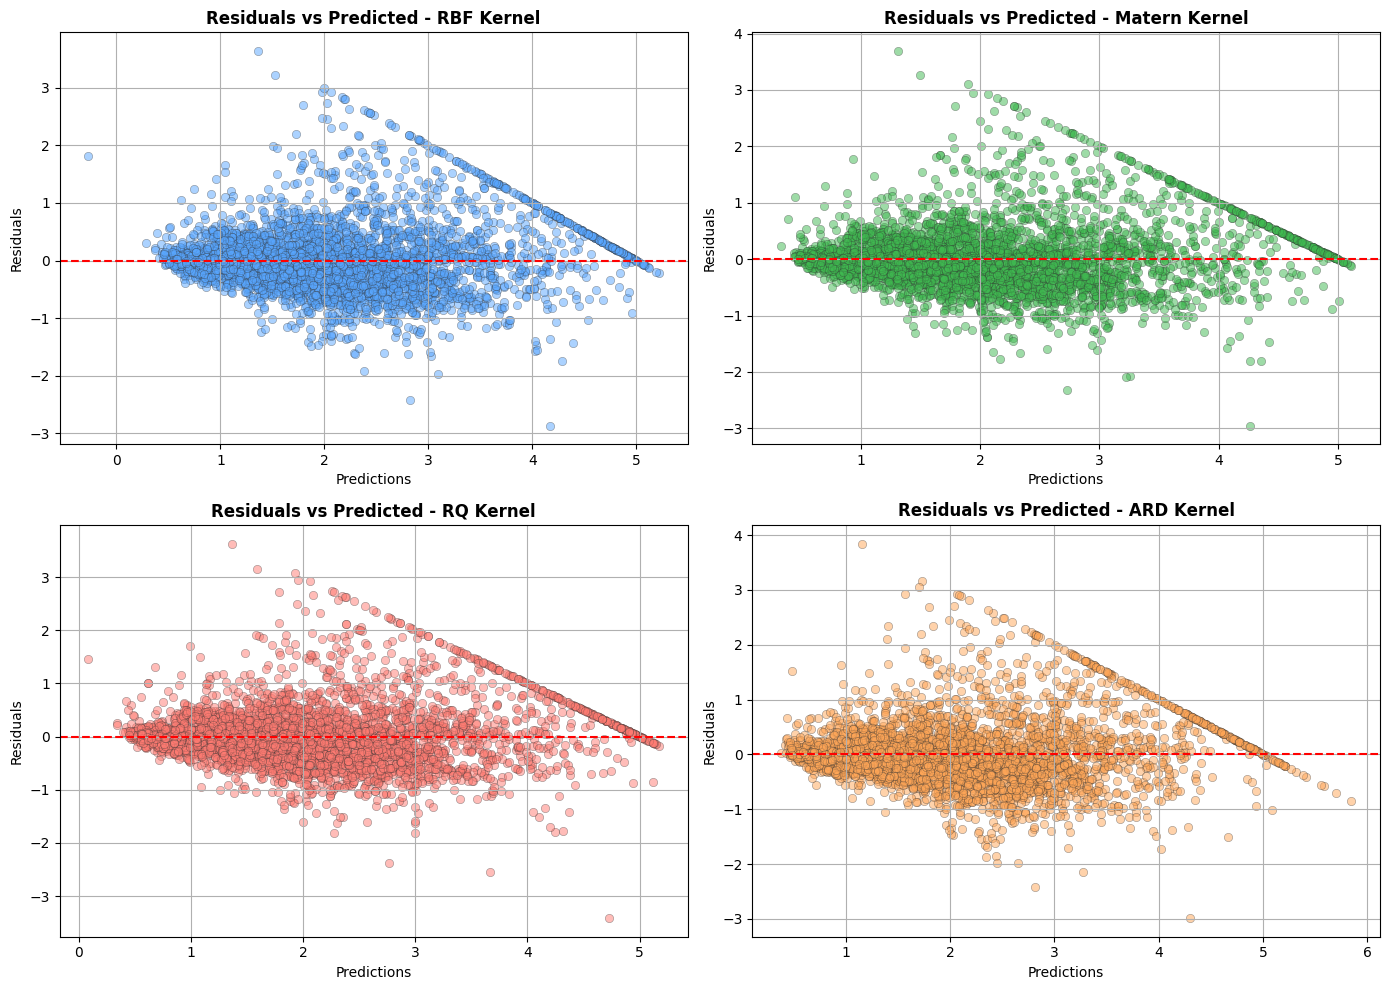

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, name in enumerate(results.keys()):
    ax  = axes[i]
    pred = results[name]["mean"]
    res = Y_test_orig - pred
    ax.scatter(pred, res, color=colors[i], alpha=0.5, edgecolors="#333", linewidths=0.4)
    ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(f"Residuals vs Predicted - {name} Kernel", fontweight="bold", fontsize=12)
    ax.set_xlabel("Predictions"); ax.set_ylabel("Residuals"); ax.grid(True)
plt.tight_layout()
plt.show()

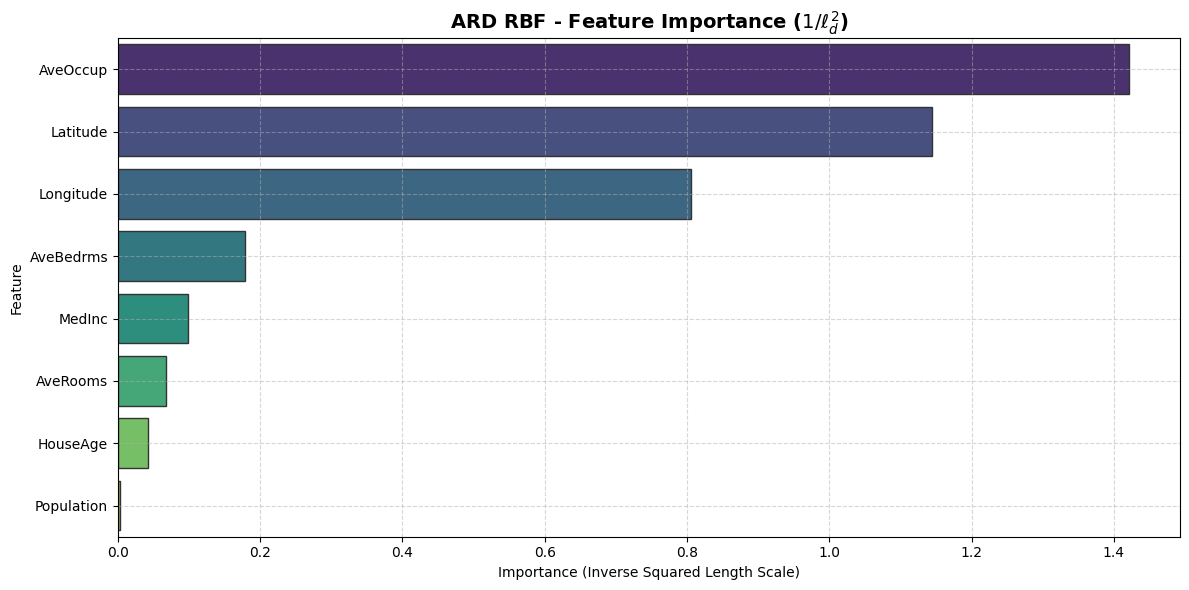

In [21]:
features = df.drop(columns=['MedHouseVal']).columns
importance = 1.0 / (ls_ard ** 2)
imp_df = pd.DataFrame({"Feature": features, "Importance": importance}).sort_values("Importance", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x="Importance", y="Feature", data=imp_df,
            palette="viridis", hue="Feature", legend=False, edgecolor="#333")
plt.title("ARD RBF - Feature Importance ($1/\\ell_d^2$)", fontweight="bold", fontsize=14)
plt.xlabel("Importance (Inverse Squared Length Scale)")
plt.ylabel("Feature")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [22]:
sample = pd.DataFrame({
    "Actual":    Y_test_orig[:20],
    "Predicted": results["Matern"]["mean"][:20],
    "Error":     np.abs(Y_test_orig[:20] - results["Matern"]["mean"][:20]),
})
print("Sample Predictions (First 20 Test Rows - Matern Kernel):")
print(sample.round(4).to_string(index=False))

Sample Predictions (First 20 Test Rows - Matern Kernel):
 Actual  Predicted  Error
  0.588     0.7879 0.1999
  1.658     1.6971 0.0391
  1.394     1.7808 0.3868
  1.075     1.5669 0.4919
  1.072     1.0407 0.0313
  3.533     3.5152 0.0178
  1.294     1.1319 0.1621
  1.131     1.0422 0.0888
  3.453     4.1676 0.7146
  2.346     2.2104 0.1356
  1.122     1.0858 0.0362
  1.358     1.1921 0.1659
  3.250     2.6995 0.5505
  0.777     1.0879 0.3109
  1.118     1.3914 0.2734
  1.350     2.0355 0.6855
  2.351     3.1344 0.7834
  1.486     1.7697 0.2837
  2.625     1.5179 1.1071
  1.482     2.7582 1.2762


In [23]:
x_new_sc = X_test[0:1]
model_mat = results["Matern"]["model"]
mu_new_sc, std_new_sc = model_mat.predict(x_new_sc, return_std=True)
pred_orig = mu_new_sc * Y_std + Y_mean
std_orig = std_new_sc * Y_std

print("Single Point Prediction (First Test Row):")
print(f"  Prediction          : {pred_orig[0]:.4f}")
print(f"  Uncertainty (sigma) : {std_orig[0]:.4f}")
print(f"  Actual              : {Y_test_orig[0]:.4f}")

Single Point Prediction (First Test Row):
  Prediction          : 0.7879
  Uncertainty (sigma) : 0.3226
  Actual              : 0.5880


### 5.6 1-D GP Visualizations

In [24]:
corr_with_target = df.corr(numeric_only=True)["MedHouseVal"].drop("MedHouseVal")
print("Correlations with MedHouseVal:")
print(corr_with_target.sort_values(ascending=False))

Correlations with MedHouseVal:
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: MedHouseVal, dtype: float64


In [25]:
def gp_plot_1d(kernel_func, title, X_gp, y_gp, X_grid, Y_std_gp, Y_mean_gp, noise_val):
    y_gp_norm = (y_gp - Y_mean_gp) / Y_std_gp
    model = GaussianProcessRegression(kernel=kernel_func, noise=noise_val)
    model.fit(X_gp, y_gp_norm)
    mean_norm, std_norm = model.predict(X_grid, return_std=True)
    mean = mean_norm * Y_std_gp + Y_mean_gp
    std = std_norm * Y_std_gp
    
    plt.figure(figsize=(14, 7))
    plt.scatter(X_gp, y_gp, s=15, alpha=0.35, color="steelblue", label="Observed Data")
    plt.plot(X_grid, mean, color="red", linewidth=2, label="GP Mean Prediction")
    plt.fill_between(X_grid.flatten(), mean - 1.96*std, mean + 1.96*std, color="red", alpha=0.15, label="95% CI")
    plt.title(title, fontweight="bold", fontsize=14)
    plt.xlabel("Feature Value")
    plt.ylabel("MedHouseVal")
    plt.legend()
    plt.grid(True)
    plt.show()

# Subsample 2000 points for 1D GP plotting speed
np.random.seed(0)
gp_sub_idx = np.random.choice(len(df), size=2000, replace=False)
df_sub = df.iloc[gp_sub_idx]

X_gp = df_sub[["MedInc"]].values
X_gp_mean = np.mean(X_gp)
X_gp_std = np.std(X_gp)
X_gp_norm = (X_gp - X_gp_mean) / X_gp_std
X_grid_raw = np.linspace(X_gp.min(), X_gp.max(), 200).reshape(-1, 1)
X_grid_norm = (X_grid_raw - X_gp_mean) / X_gp_std
y_gp = df_sub["MedHouseVal"].values
Y_gp_mean = np.mean(y_gp)
Y_gp_std = np.std(y_gp)

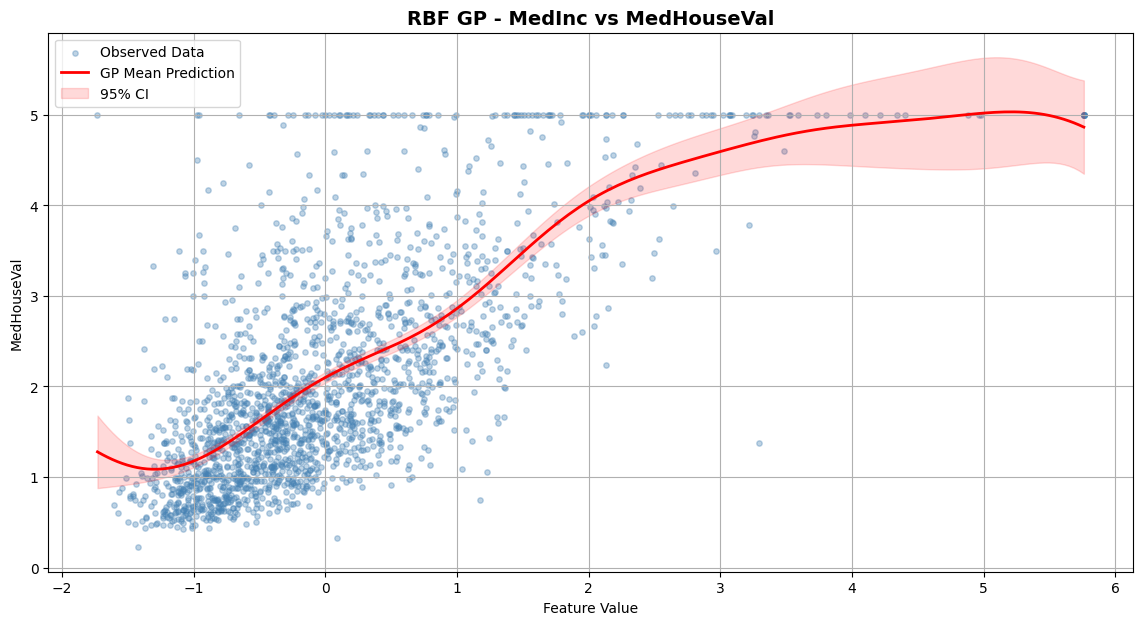

In [26]:
gp_plot_1d(lambda X1, X2: rbf_kernel(X1, X2, length_scale=1.0), "RBF GP - MedInc vs MedHouseVal", X_gp_norm, y_gp, X_grid_norm, Y_gp_std, Y_gp_mean, noise)

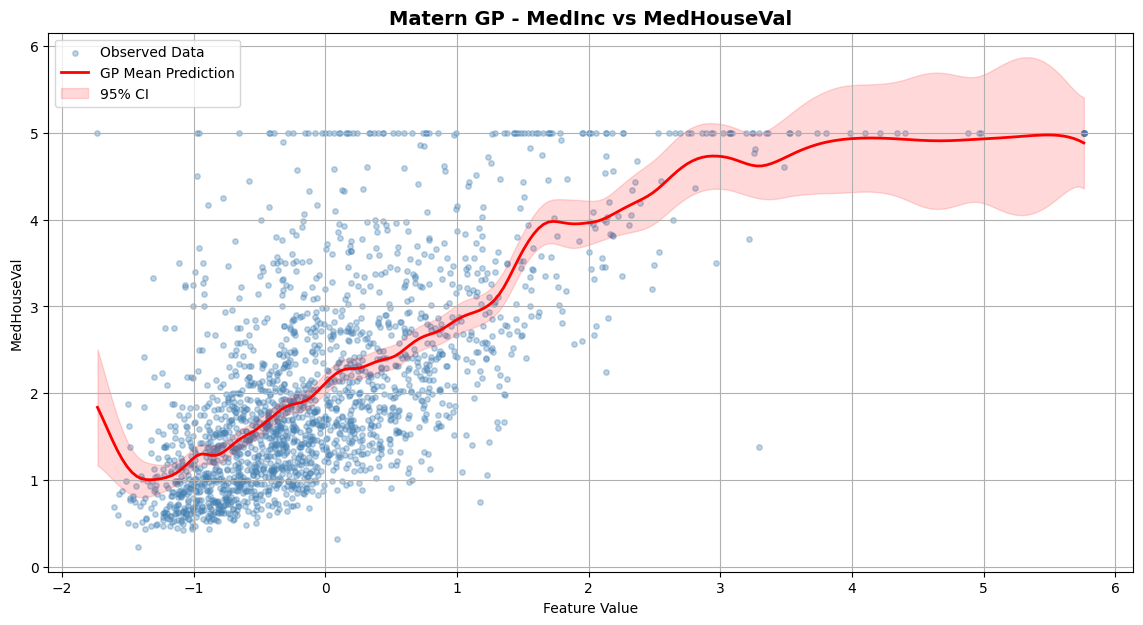

In [27]:
gp_plot_1d(lambda X1, X2: matern_kernel(X1, X2, length_scale=1.0), "Matern GP - MedInc vs MedHouseVal", X_gp_norm, y_gp, X_grid_norm, Y_gp_std, Y_gp_mean, noise)

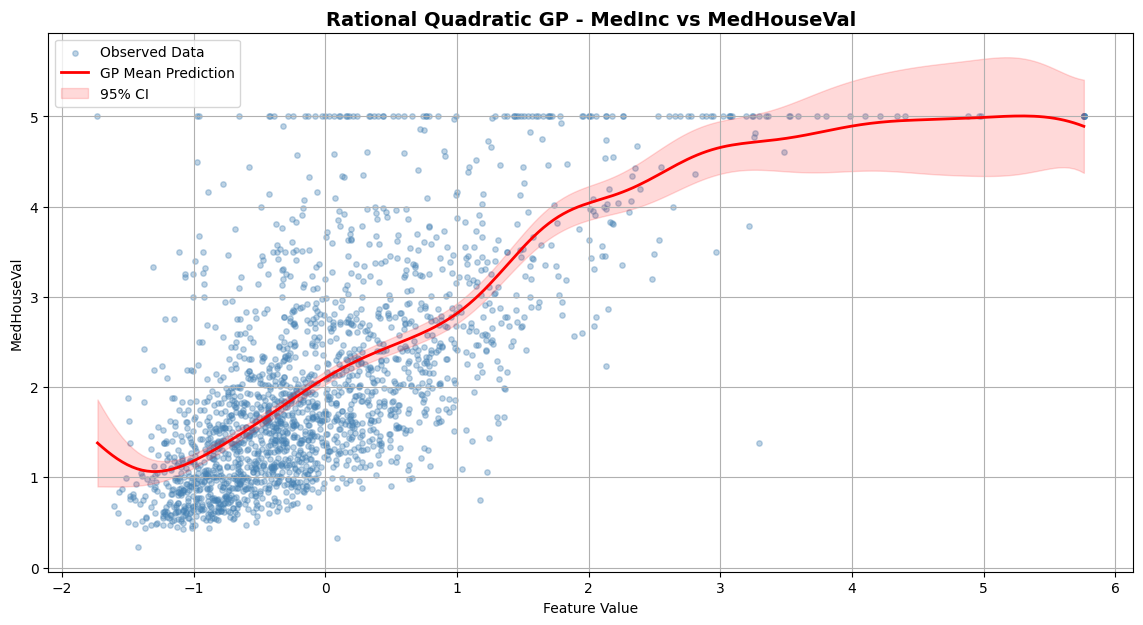

In [28]:
gp_plot_1d(lambda X1, X2: rq_kernel(X1, X2, length_scale=1.0, alpha=1.0), "Rational Quadratic GP - MedInc vs MedHouseVal", X_gp_norm, y_gp, X_grid_norm, Y_gp_std, Y_gp_mean, noise)

In [29]:
X_gp2 = df_sub[["Latitude"]].values
X_gp2_mean = np.mean(X_gp2)
X_gp2_std = np.std(X_gp2)
X_gp2_norm = (X_gp2 - X_gp2_mean) / X_gp2_std
X_grid_raw2 = np.linspace(X_gp2.min(), X_gp2.max(), 200).reshape(-1, 1)
X_grid_norm2 = (X_grid_raw2 - X_gp2_mean) / X_gp2_std
y_gp2 = df_sub["MedHouseVal"].values
Y_gp2_mean = np.mean(y_gp2)
Y_gp2_std = np.std(y_gp2)

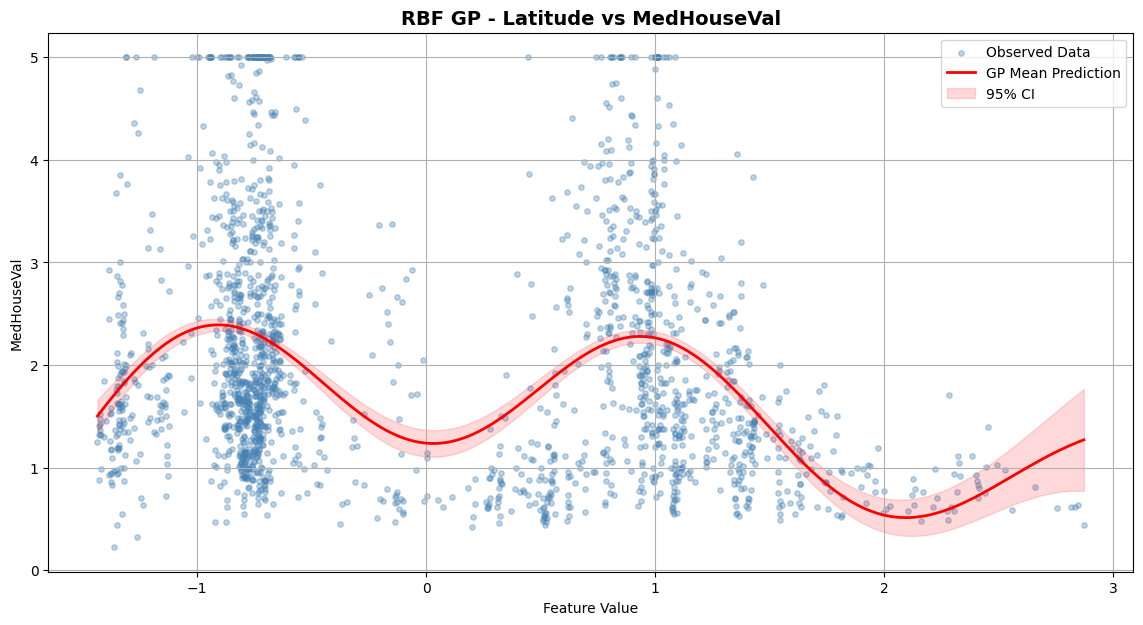

In [30]:
gp_plot_1d(lambda X1, X2: rbf_kernel(X1, X2, length_scale=1.0), "RBF GP - Latitude vs MedHouseVal", X_gp2_norm, y_gp2, X_grid_norm2, Y_gp2_std, Y_gp2_mean, noise)

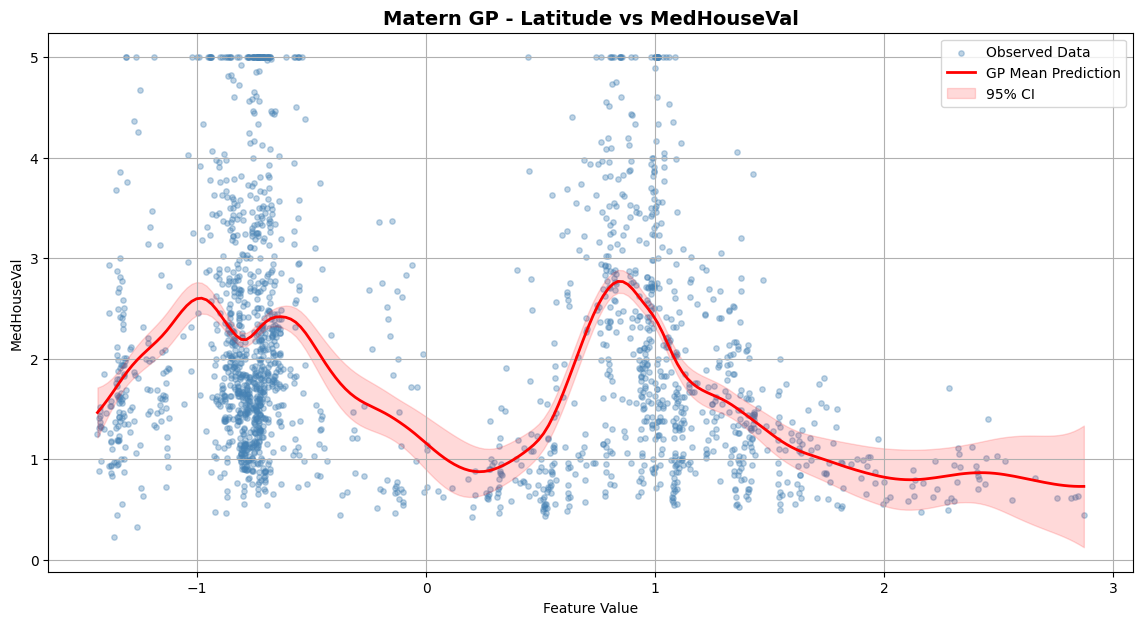

In [31]:
gp_plot_1d(lambda X1, X2: matern_kernel(X1, X2, length_scale=1.0), "Matern GP - Latitude vs MedHouseVal", X_gp2_norm, y_gp2, X_grid_norm2, Y_gp2_std, Y_gp2_mean, noise)

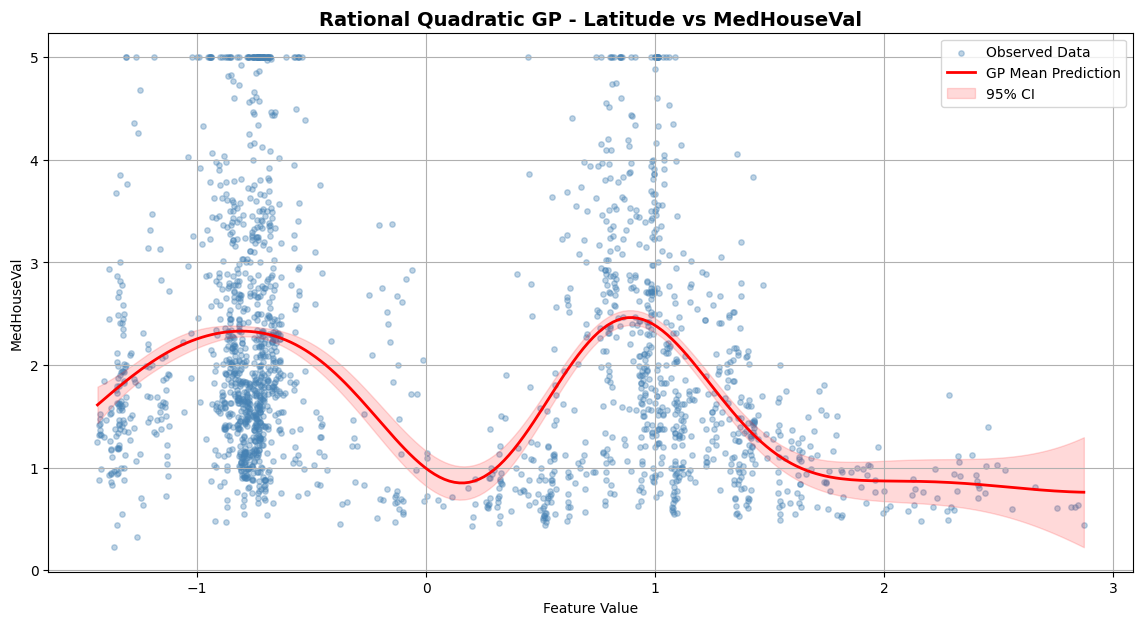

In [32]:
gp_plot_1d(lambda X1, X2: rq_kernel(X1, X2, length_scale=1.0, alpha=1.0), "Rational Quadratic GP - Latitude vs MedHouseVal", X_gp2_norm, y_gp2, X_grid_norm2, Y_gp2_std, Y_gp2_mean, noise)

## 6. Comparison with Baseline Machine Learning Models

We implement Linear Regression, Polynomial Regression (Deg 2), KNN, and Decision Tree regressors entirely from scratch using NumPy.

In [33]:
class LinearRegressionFromScratch:
    def fit(self, X, y):
        X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
        self.w = np.linalg.solve(X_bias.T @ X_bias + 1e-8 * np.eye(X_bias.shape[1]), X_bias.T @ y)
    def predict(self, X):
        X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
        return X_bias @ self.w

class PolynomialRegressionFromScratch:
    def __init__(self, degree=2):
        self.degree = degree
    def fit(self, X, y):
        features = [X**i for i in range(1, self.degree + 1)]
        X_poly = np.hstack(features)
        X_bias = np.hstack([np.ones((X_poly.shape[0], 1)), X_poly])
        self.w = np.linalg.solve(X_bias.T @ X_bias + 1e-8 * np.eye(X_bias.shape[1]), X_bias.T @ y)
    def predict(self, X):
        features = [X**i for i in range(1, self.degree + 1)]
        X_poly = np.hstack(features)
        X_bias = np.hstack([np.ones((X_poly.shape[0], 1)), X_poly])
        return X_bias @ self.w

class KNNRegressorFromScratch:
    def __init__(self, k=5):
        self.k = k
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    def predict(self, X):
        # Vectorized fast pairwise distance computation
        X_sq = np.sum(X**2, axis=1, keepdims=True)
        X_train_sq = np.sum(self.X_train**2, axis=1, keepdims=True).T
        dists = np.maximum(X_sq + X_train_sq - 2 * X @ self.X_train.T, 0.0)
        idx_knn = np.argpartition(dists, self.k, axis=1)[:, :self.k]
        knn_y = self.y_train[idx_knn]
        return np.mean(knn_y, axis=1)

class DecisionTreeRegressorFromScratch:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None
    def fit(self, X, y):
        self.tree = self._build_tree(X, y, depth=0)
    def _build_tree(self, X, y, depth):
        num_samples, num_features = X.shape
        if depth >= self.max_depth or num_samples < self.min_samples_split or np.std(y) == 0:
            return np.mean(y)
        best_feat, best_thresh, best_mse = None, None, float('inf')
        for feat in range(num_features):
            thresholds = np.unique(X[:, feat])
            if len(thresholds) > 100:
                thresholds = np.percentile(thresholds, np.linspace(0, 100, 50))
            for thresh in thresholds:
                left_mask = X[:, feat] <= thresh
                right_mask = ~left_mask
                if not np.any(left_mask) or not np.any(right_mask):
                    continue
                left_y, right_y = y[left_mask], y[right_mask]
                mse = np.sum((left_y - np.mean(left_y))**2) + np.sum((right_y - np.mean(right_y))**2)
                if mse < best_mse:
                    best_mse = mse
                    best_feat = feat
                    best_thresh = thresh
        if best_feat is None:
            return np.mean(y)
        left_mask = X[:, best_feat] <= best_thresh
        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[~left_mask], y[~left_mask], depth + 1)
        return {"feature": best_feat, "threshold": best_thresh, "left": left_child, "right": right_child}
    def predict(self, X):
        return np.array([self._predict_row(self.tree, row) for row in X])
    def _predict_row(self, node, row):
        if not isinstance(node, dict):
            return node
        if row[node["feature"]] <= node["threshold"]:
            return self._predict_row(node["left"], row)
        else:
            return self._predict_row(node["right"], row)


In [34]:
models_baseline = {
    "Linear Regression": LinearRegressionFromScratch(),
    "Polynomial Regression (Deg 2)": PolynomialRegressionFromScratch(degree=2),
    "K-Nearest Neighbors": KNNRegressorFromScratch(k=5),
    "Decision Tree": DecisionTreeRegressorFromScratch(max_depth=5)
}

trained_baselines = {}
for name, model in models_baseline.items():
    model.fit(X_train, Y_train_orig)
    trained_baselines[name] = model
    print(f"Baseline '{name}' trained from scratch.")

Baseline 'Linear Regression' trained from scratch.
Baseline 'Polynomial Regression (Deg 2)' trained from scratch.
Baseline 'K-Nearest Neighbors' trained from scratch.
Baseline 'Decision Tree' trained from scratch.


In [35]:
# Implement regression metrics from scratch
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true))
baseline_results = []
for name, model in trained_baselines.items():
    y_pred = model.predict(X_test)
    rmse_val = np.sqrt(mean_squared_error(Y_test_orig, y_pred))
    mae_val = mean_absolute_error(Y_test_orig, y_pred)
    r2_val = r2_score(Y_test_orig, y_pred)
    mape_val = mean_absolute_percentage_error(Y_test_orig, y_pred)
    baseline_results.append([name, rmse_val, mae_val, r2_val, mape_val])

baseline_df = pd.DataFrame(
    baseline_results,
    columns=["Model", "RMSE", "MAE", "R2", "MAPE"]
)
baseline_df = baseline_df.sort_values("RMSE")
print(baseline_df)

                           Model      RMSE       MAE        R2      MAPE
2            K-Nearest Neighbors  0.652351  0.443630  0.683830  0.237376
3                  Decision Tree  0.733951  0.533499  0.599785  0.322979
0              Linear Regression  0.745104  0.542190  0.587529  0.319600
1  Polynomial Regression (Deg 2)  0.754783  0.532936  0.576744  0.311650


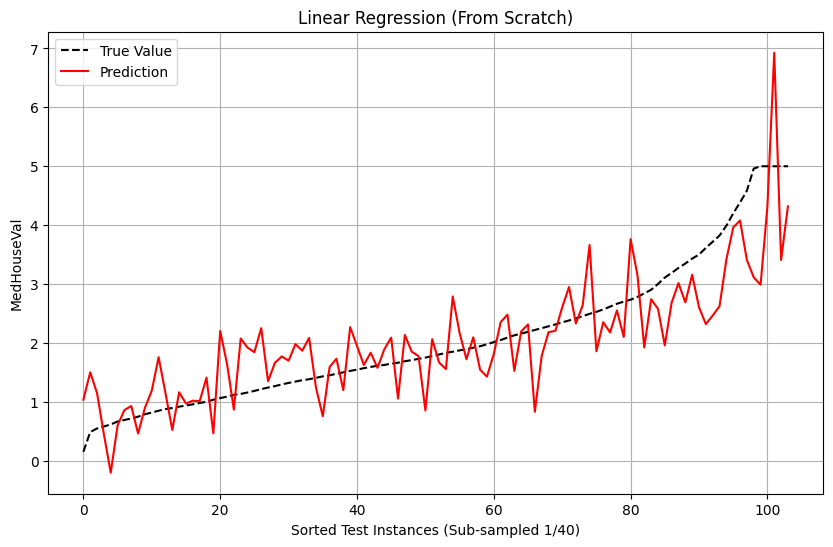

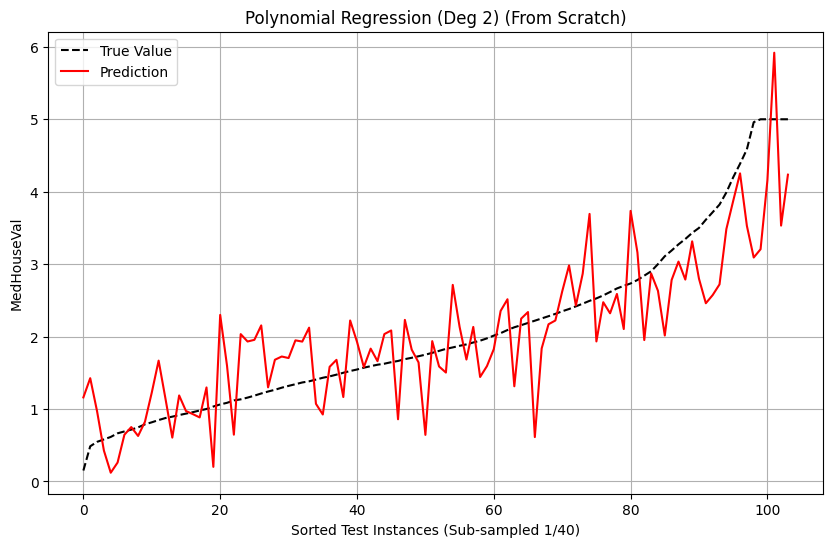

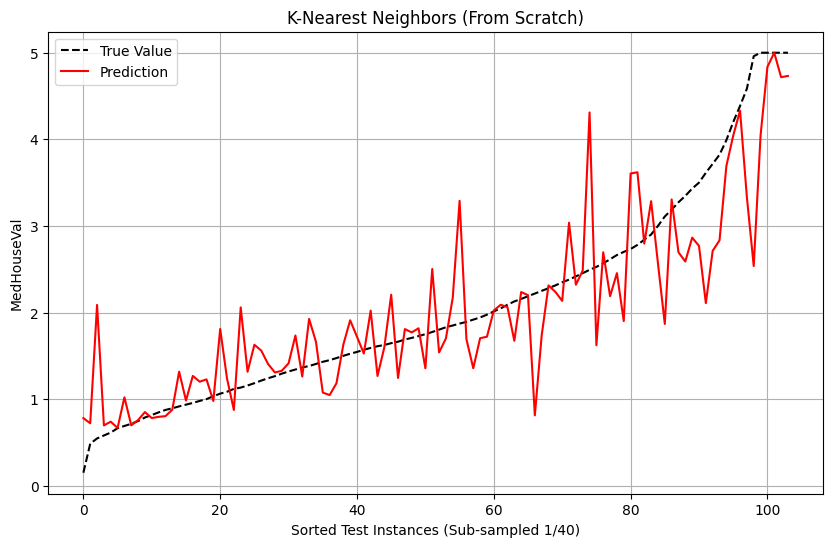

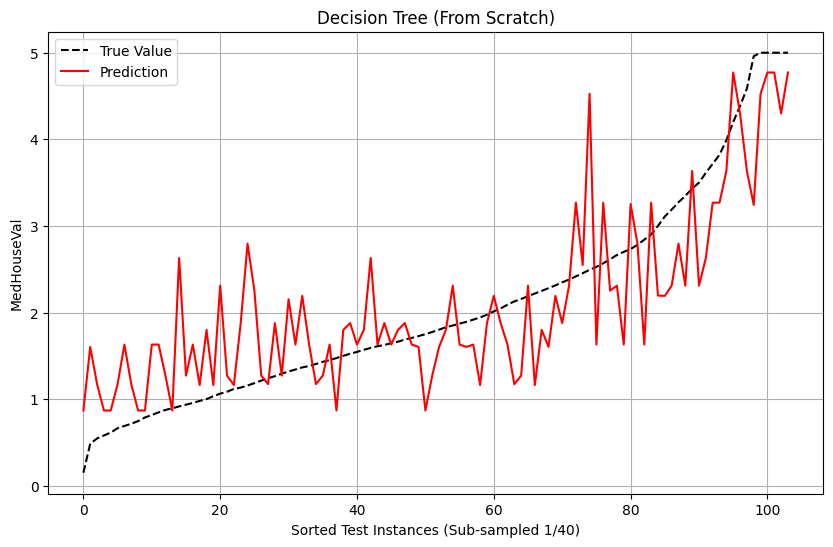

In [37]:
for name, model in trained_baselines.items():
    y_pred = model.predict(X_test)
    plt.figure(figsize=(10,6))
    # Use the same sub-sampled plot_idx to align dimensions
    plt.plot(x_axis, y_pred[plot_idx], 'r-', label='Prediction', linewidth=1.5)
    plt.plot(x_axis, Y_test_sorted, 'k--', label='True Value', linewidth=2.0)
    plt.title(f"{name} (From Scratch)")
    plt.xlabel("Sorted Test Instances (Sub-sampled 1/40)")
    plt.ylabel("MedHouseVal")
    plt.legend()
    plt.grid(True)
    plt.show()


## 7. Summary and Model Ranking

In [38]:
joint_results = []
for name in results.keys():
    pred = results[name]["mean"]
    rmse_val = np.sqrt(np.mean((Y_test_orig - pred)**2))
    mape_val = mean_absolute_percentage_error(Y_test_orig, pred)
    accuracy = 100 * (1 - mape_val)
    joint_results.append([f"GPR ({name})", rmse_val, accuracy])
    
for name, model in trained_baselines.items():
    pred = model.predict(X_test)
    rmse_val = np.sqrt(mean_squared_error(Y_test_orig, pred))
    mape_val = mean_absolute_percentage_error(Y_test_orig, pred)
    accuracy = 100 * (1 - mape_val)
    joint_results.append([name, rmse_val, accuracy])
    
ranking_df = pd.DataFrame(joint_results, columns=["Model", "RMSE", "Accuracy (%)"])
ranking_df = ranking_df.sort_values("RMSE")
print(ranking_df)

                           Model      RMSE  Accuracy (%)
2                       GPR (RQ)  0.552962     78.907297
1                   GPR (Matern)  0.554475     78.916230
0                      GPR (RBF)  0.561079     78.333351
3                      GPR (ARD)  0.562854     78.979730
6            K-Nearest Neighbors  0.652351     76.262392
7                  Decision Tree  0.733951     67.702135
4              Linear Regression  0.745104     68.039957
5  Polynomial Regression (Deg 2)  0.754783     68.834986


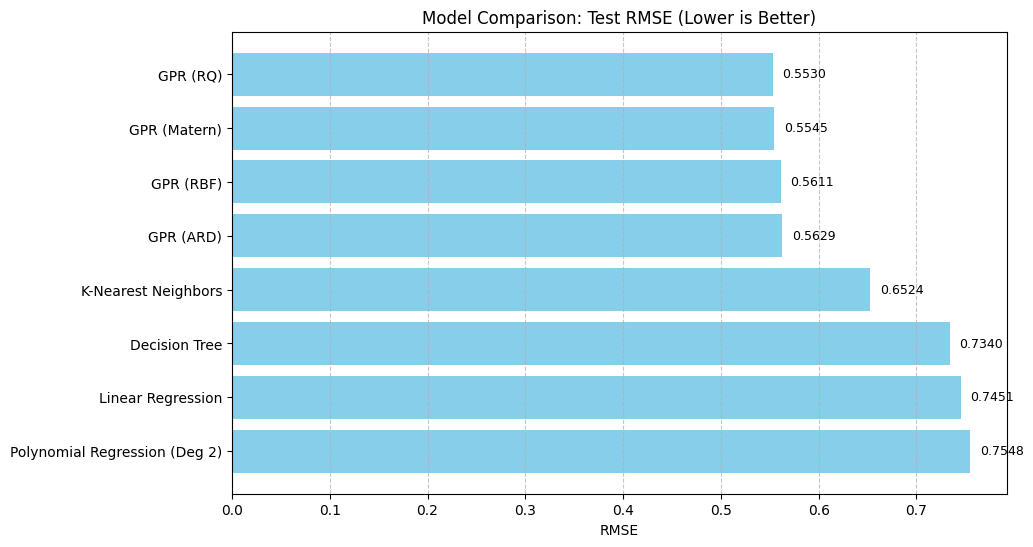

In [39]:
ranking_df_sorted_rmse = ranking_df.sort_values("RMSE", ascending=True)
plt.figure(figsize=(10,6))
bars = plt.barh(ranking_df_sorted_rmse["Model"], ranking_df_sorted_rmse["RMSE"], color='skyblue')
plt.xlabel("RMSE")
plt.title("Model Comparison: Test RMSE (Lower is Better)")
plt.gca().invert_yaxis()
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f"{width:.4f}", 
             va='center', ha='left', fontsize=9)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()

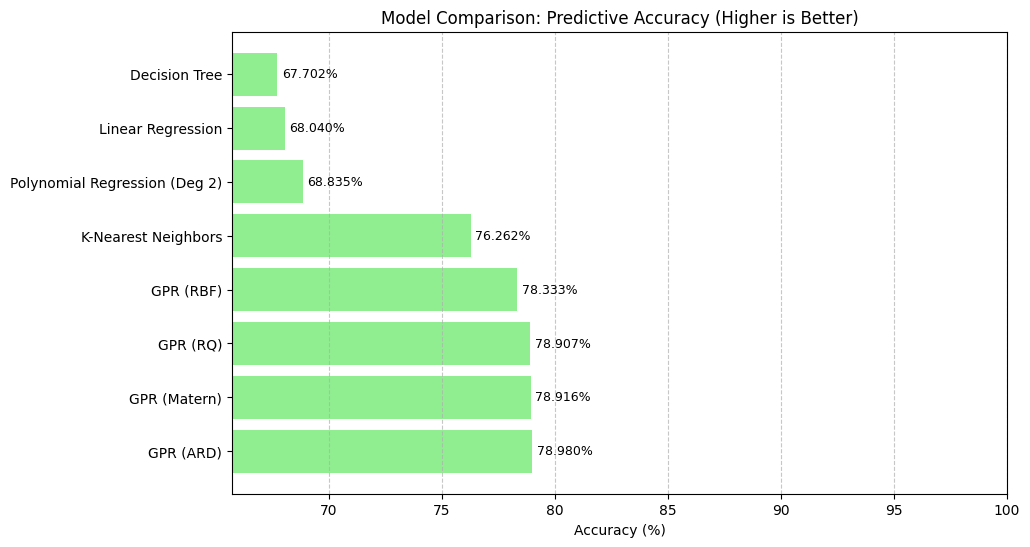

In [40]:
ranking_df_sorted_acc = ranking_df.sort_values("Accuracy (%)", ascending=False)
plt.figure(figsize=(10,6))
bars = plt.barh(ranking_df_sorted_acc["Model"], ranking_df_sorted_acc["Accuracy (%)"], color='lightgreen')
plt.xlabel("Accuracy (%)")
plt.title("Model Comparison: Predictive Accuracy (Higher is Better)")
plt.xlim(ranking_df["Accuracy (%)"].min() - 2, 100)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2, f"{width:.3f}%", 
             va='center', ha='left', fontsize=9)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()